# S2 Coursework
fl482

### Import dependencies

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import scipy.integrate as integrate
import emcee
import corner

## Ex 1

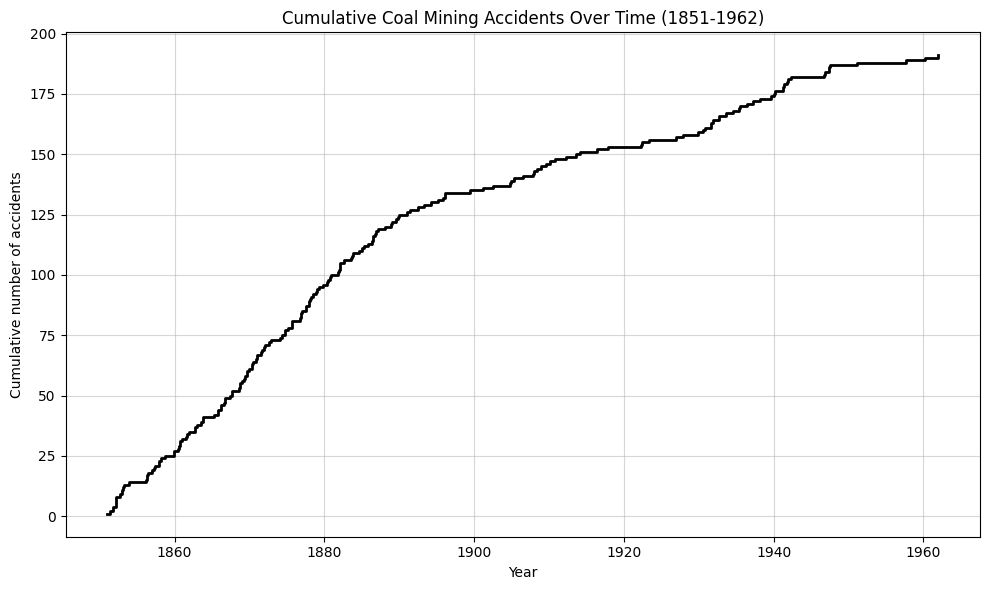

Total number of accidents (N): 191
Total period in days (L): 40550
Mean rate of accidents: 0.004710 accidents/day
Mean rate of accidents: 1.72 accidents/year


In [43]:
# load data and find N and L
data = np.loadtxt('coal_mining_accident_data.dat').flatten(order='F')
L = 40550
N = len(data) + 1 

# plot the cumulative number of accidents over time.
accident_times = np.concatenate(([0], np.cumsum(data)))
cumulative_accidents = np.arange(1, len(accident_times) + 1)

# days to years
accident_times_years = 1851 + (accident_times / 365.25)

plt.figure(figsize=(10, 6))

# Plot using the years array
plt.step(accident_times_years, cumulative_accidents, where='post', color='k', linewidth=2)
plt.hlines(y=N, xmin=accident_times_years[-1], xmax=1851 + L/365.25, color='k', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Cumulative number of accidents')
plt.title('Cumulative Coal Mining Accidents Over Time (1851-1962)')
plt.grid(True, alpha=0.5)

plt.savefig('figs/Ex1a.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

# calc mean
mean_rate = N / L

print(f"Total number of accidents (N): {N}")
print(f"Total period in days (L): {L}")
print(f"Mean rate of accidents: {mean_rate:.6f} accidents/day")
print(f"Mean rate of accidents: {mean_rate * 365.25:.2f} accidents/year")


## Ex 2 

### a

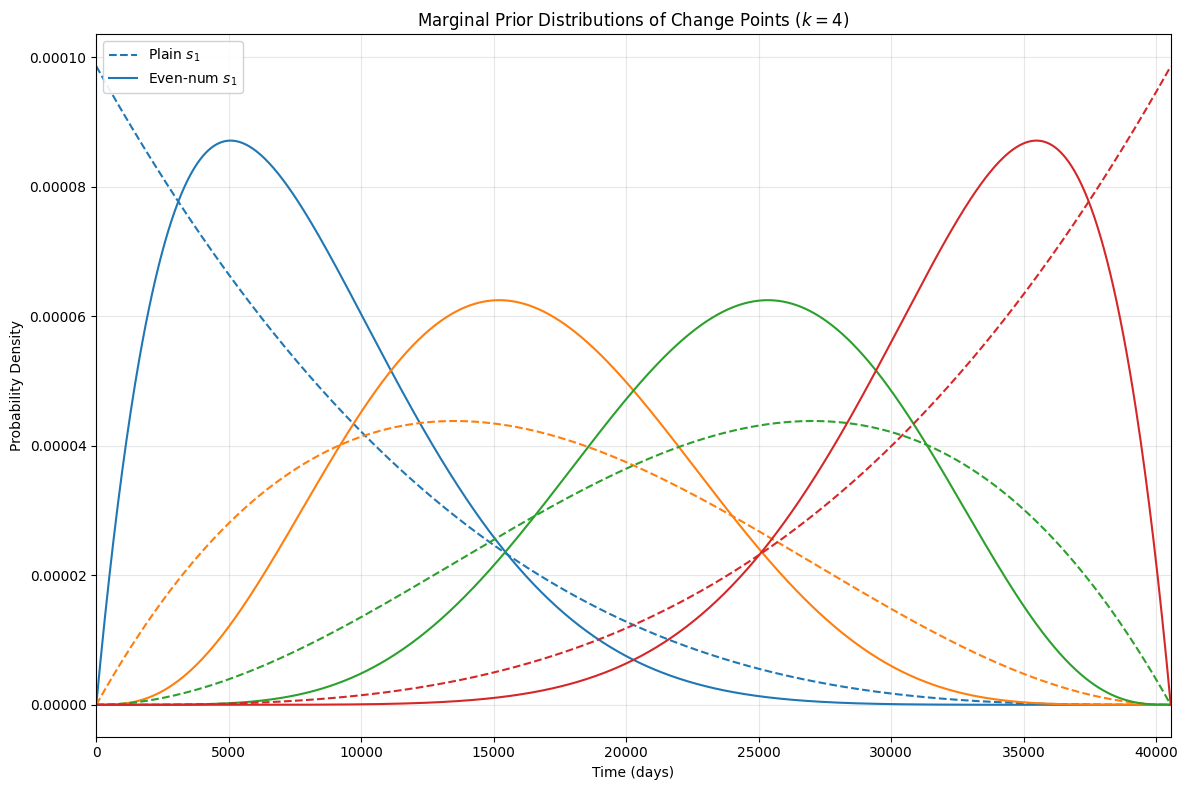

In [22]:
# params
L = 40550
k = 4
N_sim = 10000

s = np.linspace(0, L, 1000)

plt.figure(figsize=(12, 8))

for j in range(1, k + 1):
    # plain order
    dist_plain = beta(j, k - j + 1)
    
    # even numbered order
    dist_even = beta(2*j, 2*k - 2*j + 2)
    
    color = plt.cm.tab10(j-1)
    plt.plot(s, dist_plain.pdf(s/L)/L, color=color, linestyle='--', 
             label=f'Plain $s_{j}$' if j==1 else "")
    plt.plot(s, dist_even.pdf(s/L)/L, color=color, linestyle='-', 
             label=f'Even-num $s_{j}$' if j==1 else "")

plt.title(f'Marginal Prior Distributions of Change Points ($k={k}$)')
plt.xlabel('Time (days)')
plt.ylabel('Probability Density')
plt.xlim(0, L)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.savefig('figs/Ex2a.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
#TODO check answer for 2a

### b

To derive the even-numbered pdf we start with the fact that the plain ordered pdf for $2k+1$ points on the unit interval $[0, 1]$ is a constant

$$P(u_{(1)}, u_{(2)}, \dots, u_{(2k+1)}) = (2k + 1)!$$

This is valid only on the strictly ordered region $0 < u_{(1)} < u_{(2)} < \dots < u_{(2k+1)} < 1$.

For the even numbered pdf we only keep even-numbered order statistics $\hat{s}_j = u_{(2j)}$ so must marginalise the plain order pdf over all the other discarded points. We know that the points are ordered and on the unit interval $[0, 1]$ so the integral is

$$P(\hat{s}_1, \dots, \hat{s}_k) = \int_{0}^{\hat{s}_1} \int_{\hat{s}_1}^{\hat{s}_2} \dots \int_{\hat{s}_k}^{1} (2k + 1)! \, du_{(2k+1)} \dots du_{(3)} du_{(1)}$$

Because the integrand $(2k+1)!$ is a constant, each integral becomes the length of the interval between the 2 points on the bounds, or the gap $\hat{g}_j$ between them.

$$P(\hat{s}_1, \dots, \hat{s}_k) = (2k + 1)! (\hat{s}_1)(\hat{s}_2 - \hat{s}_1)\dots(1 - \hat{s}_k)$$

$$=  (2k + 1)! \prod_{j=1}^{k+1} \hat{g}_j$$

We now need to map this from the unit interval $[0, 1]$ to the actual timeline $[0, L]$. We are given the scaling relationship $s_j = L\hat{s}_j$ so can scale the gaps according to $\hat{g}_j = g_j / L$ and substitute this into the equation

$$P(\hat{s}_1, \dots, \hat{s}_k) = (2k + 1)! \prod_{j=1}^{k+1} \left( \frac{g_j}{L} \right)$$

Since $L$ is a constant it can be pulled out of the product

$$P(\hat{s}_1, \dots, \hat{s}_k) = \frac{(2k + 1)!}{L^{k+1}} \prod_{j=1}^{k+1} \left( g_j \right)$$

We must then apply the change of variables formula 

$$P(s_1, \dots, s_k) = P(\hat{s}_1, \dots, \hat{s}_k) \times \left| J \right|$$

where $|J|$ is the Jacobian determinant of the transformation. 

Since $s_j = L \hat{s}_j$, the inverse transformation is $\hat{s}_j = \frac{s_j}{L}$. Taking the derivative of each variable gives $\frac{\partial \hat{s}_j}{\partial s_j} = \frac{1}{L}$. The Jacobian determinant is then given by the product of the derivatives and since there are $k$ points,

$$\left| J \right| = \left( \frac{1}{L} \right)^k = \frac{1}{L^k}$$

This allows us to obtain the final pdf

$$\pi(s_1, s_2, \dots, s_k | M_k) = \frac{(2k+1)!}{L^{2k+1}} \prod_{j=1}^{k+1} g_j$$

$$\pi(s_1, s_2, \dots, s_k | M_k) \propto \prod_{j=1}^{k+1} g_j$$


## Exercise 3

### a

From the instructions, the continuous process log-likelihood is given by $$\log \mathcal{L}(h_0| M_0) = \sum_{i=1}^{N} \log x(y_i) - \int_{0}^{L} x(t) dt $$ Since $x(t) = h_0$ is a constant over the interval $L$ $$\log \mathcal{L}(h_0 | M_0) = N \log(h_0) - h_0 L$$ The likelihood is therefore $$\mathcal{L}({I_i} | h_0, M_0) = h_0^N \exp(-h_0 L)$$

From Exercise 2, the prior for the height parameters is universally given by a Gamma distribution $h_0 \sim \Gamma(\alpha, \beta)$ where $\alpha=1$ and $\beta=200$. This forms the probability density function: $$ \pi(h_0|M_0) = \frac{\beta^\alpha}{\Gamma(\alpha)} h_0^{\alpha-1} \exp(-\beta h_0) $$ Since $\alpha=1$ and $\Gamma(1) = 1$, the prior simplifies exactly to an Exponential distribution: $$ \pi(h_0|M_0) = \beta \exp(-\beta h_0) = 200 \exp(-200 h_0) $$

Using Bayes' theorem, the posterior is proportional to the Likelihood $\times$ Prior. $$ P^(h_0 | {I_i}, M_0) = h_0^N \exp(-h_0 L) \cdot \beta \exp(-\beta h_0) $$ $$ P^(h_0 | {I_i}, M_0) = \beta \cdot h_0^N \exp(-h_0(L + \beta)) $$

If you try to compute this directly using floating-point code, you will encounter immediate computational underflow. Computing $h_0^{191}$ when $h_0 \approx 0.005$ yields numbers heavily below the 64-bit float limit of $10^{-308}$ and evaluates purely to $0.0$.

Step 4: Handle Underflow using the Log-Shift Trick
Instead of directly integrating the tiny numbers, you must integrate the exponentiated shifted log-posterior.

Define the log-unnormalized posterior: $$ f(h_0) = \log(P^*) = \log(\beta) + N \log(h_0) - h_0(L + \beta) $$
Find the maximum height of this curve using analytical calculus (taking the derivative and setting it to zero): $$ h_{max} = \frac{N}{L + \beta} $$
Let $C = f(h_{max})$ be the peak log-value. You can express the unnormalized posterior safely as: $$ P^*(h_0) = \exp(C) \cdot \exp(f(h_0) - C) $$
Step 5: Perform the 1D Numerical Integration
To find the evidence $Z_0$, you need to integrate $P^(h_0)$ from $0 \rightarrow \infty$: $$ Z_0 = \int_{0}^{\infty} P^(h_0) dh_0 = \exp(C) \int_{0}^{\infty} \exp(f(h_0) - C) dh_0 $$

In Python, you can write a helper to evaluate the log evidence to prevent printing $0.0$:

Step 6: Normalise the Posterior & Plot
You now have your $\log Z_0$. You can get the exact, normalized posterior back safely by using: $$ P(h_0 | {I_i}, M_0) = \exp(f(h_0) - \log Z_0) $$

Create an array of heights (e.g., np.linspace(0, 0.02, 1000)) and plot both curves:

The prior: $200 \exp(-200 h_0)$
The posterior: $\exp(f(h_0) - \log Z_0)$
Sanity Check Note: Analytically, the posterior distribution takes the form of $\Gamma(N + 1, L + \beta) = \Gamma(192, 40750)$. The numerical integration normalized posterior should identically match this Gamma distribution exactly, which helps you verify that your code works.

Log Evidence (ln Z0): -1217.09, error 8.621628018868622e-11


/var/folders/q5/m4w7tpr13hs_7wkk75z6xxb80000gn/T/ipykernel_84365/2062453617.py:9: RuntimeWarning: divide by zero encountered in log
  return np.log(beta) + N * np.log(h0) - h0 * (L + beta)


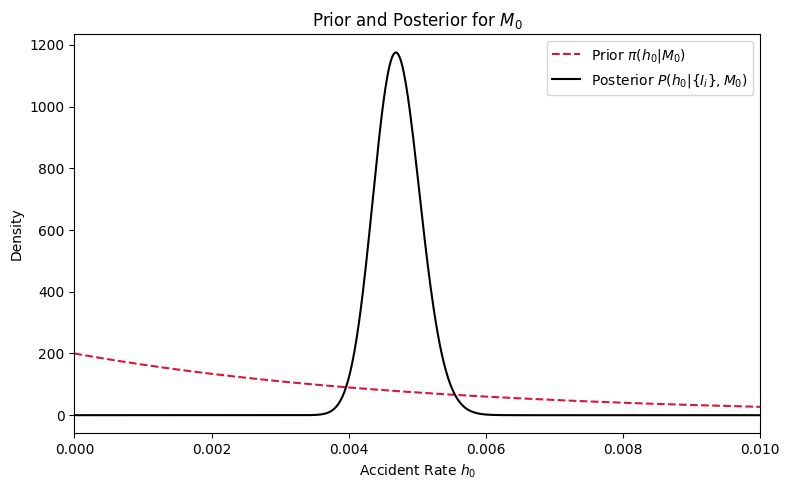

In [101]:
L = 40550
N = 191 
alpha = 1
beta = 200

# log unnormalised posterior
def log_unnorm_posterior(h0):
    # f(h0) = log(beta) + N*log(h0) - h0*(L + beta)
    return np.log(beta) + N * np.log(h0) - h0 * (L + beta)

# find c
h_max = N / (L + beta)
C = log_unnorm_posterior(h_max)

# shifted posterior: exp(f(h0) - C)
def shifted_posterior(h0):
    return np.exp(log_unnorm_posterior(h0) - C)

# numerical integration using scipy.integrate.quad
integral_value, error = integrate.quad(shifted_posterior, 0, 0.008)
log_Z0 = C + np.log(integral_value)
print(f"Log Evidence (ln Z0): {log_Z0:.2f}, error {error}")

# prior and posterior
h_vals = np.linspace(0, 0.015, 1000)
prior = (beta * np.exp(-beta * h_vals))
posterior = (np.exp(log_unnorm_posterior(h_vals) - log_Z0))

plt.figure(figsize=(8, 5))
plt.plot(h_vals, prior, label=r'Prior $\pi(h_0|M_0)$', linestyle='--', c='crimson')
plt.plot(h_vals, posterior, label=r'Posterior $P(h_0|\{I_i\},M_0)$', color='k')

plt.xlabel(r'Accident Rate $h_0$')
plt.ylabel('Density')
plt.title(r'Prior and Posterior for $M_0$')
plt.xlim(0, 0.01)
plt.legend()

plt.savefig('figs/Ex3a.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()


## Exercise 4

### a

- Integrated Autocorrelation Time ($\tau$): To ensure you have enough independent samples.
- Gelman-Rubin ($\hat{R}$): To ensure multiple chains have converged to the same distribution.
- Trace Plots: To visually confirm "fuzzy caterpillar" behavior.

warmup and thinning

In [81]:
# funcs for emcee

L = 40550
beta = 200

def log_prior(theta):
    s1, h0, h1 = theta

    # check bounds
    if not (0 < s1 < L) or h0 <= 0 or h1 <= 0:
        return -np.inf
    
    # log position prior 6/L^3 * s1 * (L - s_1)
    log_pos_prior = np.log(6) - 3*np.log(L) + np.log(s1) + np.log(L - s1)
    
    # log height prior 200 * exp(-200 * h)
    log_height_prior = 2 * np.log(beta) - beta * (h0 + h1)
    
    return log_pos_prior + log_height_prior

def log_likelihood(theta, y):
    s1, h0, h1 = theta
    
    # count how many accidents happened before and after the change point
    N0 = np.sum(y < s1)
    N1 = len(y) - N0
    
    # log likelihood N_0log(h_0) + N_1log(h_1) -( h_0s_1  h_1(L - s_1))
    return N0*np.log(h0) + N1*np.log(h1) -(h0*s1 + h1*(L - s1))

def log_posterior(theta, y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, y)

In [104]:
# load data + constants
data = np.loadtxt('coal_mining_accident_data.dat').flatten(order='F')
N = 191
L = 40550
beta = 200
y = np.concatenate(([0], np.cumsum(data)))

np.random.seed(68)

# MCMC settings
ndim = 3          # num params [s1, h0, h1]
nwalkers = 32     # num walkers
nsteps = 8000     # steps per walker

# init walkers
initial_s1 = np.random.uniform(1000, L - 1000, nwalkers) # - s1 [1000, L]
initial_h0 = np.random.normal(0.005, 0.001, nwalkers) # - h0, h1 based on constant model
initial_h1 = np.random.normal(0.005, 0.001, nwalkers)

# combine into a (nwalkers, ndim) array
p0 = np.vstack([initial_s1, initial_h0, initial_h1]).T

# all heights positive
p0[:, 1:] = np.abs(p0[:, 1:]) 

# run sampler
print("Running MCMC...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(y,))
sampler.run_mcmc(p0, nsteps, progress=True)
print('Finished')

Running MCMC...


100%|██████████| 8000/8000 [00:03<00:00, 2523.90it/s]

Finished


Autocorrelation time for [s1, h0, h1]: [46.63421252 47.73744334 47.25232376]


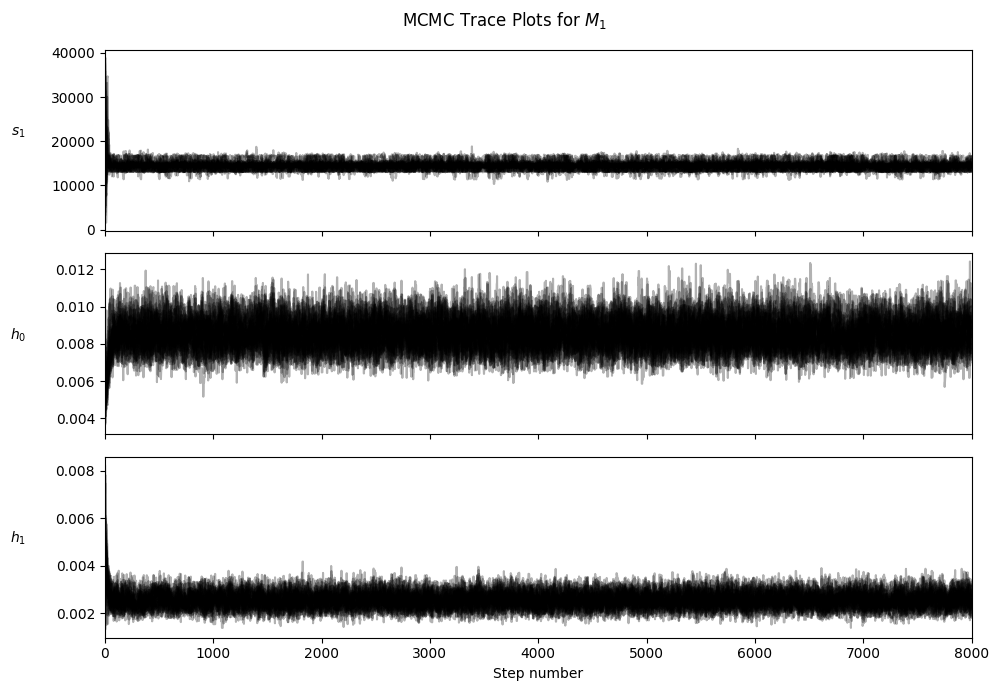

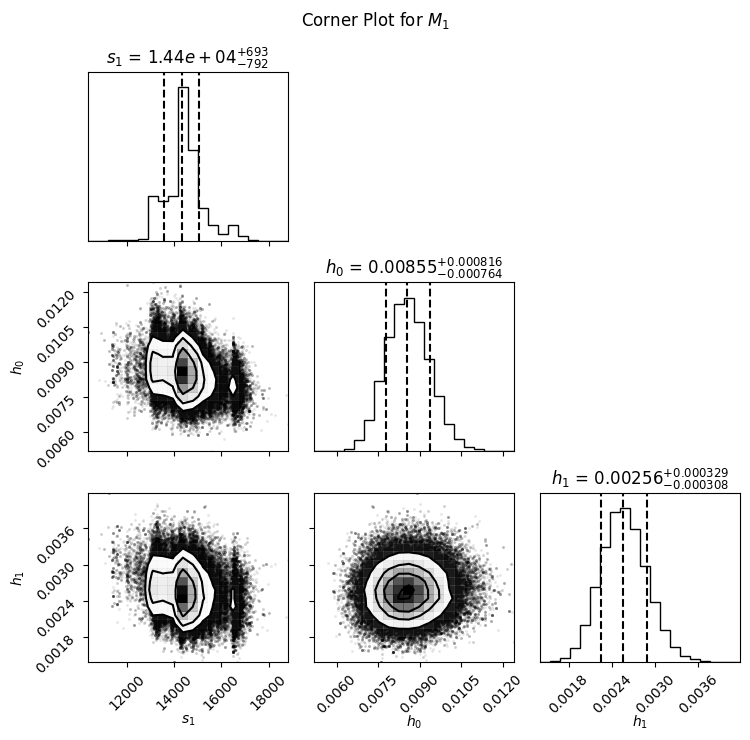

In [111]:
tau = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation time for [s1, h0, h1]: {tau}")

# trace plots
# This plots the path of every walker over time to check for convergence
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$s_1$", "$h_0$", "$h_1$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i], rotation=0)
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Step number")
fig.suptitle(r"MCMC Trace Plots for $M_1$")

plt.tight_layout()
plt.savefig('figs/Ex4a_traces.pdf', bbox_inches='tight')
plt.show()

# get results
burnin = 500
flat_samples = sampler.get_chain(discard=burnin, flat=True)

# corner plot
fig = corner.corner(
    flat_samples, labels=labels, truths=None,
    quantiles=[0.16, 0.5, 0.84], # Shows the 1-sigma uncertainty regions
    show_titles=True, title_kwargs={"fontsize": 12}, title_fmt=".3g"
)
fig.suptitle(r"Corner Plot for $M_1$")

plt.tight_layout()
plt.savefig('figs/Ex4a_corner.pdf', bbox_inches='tight')
plt.show()